## Closeness Metric

In [23]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from gensim.corpora import Dictionary
from gensim.models import LdaModel

In [ ]:
# File Paths
CS_COURSE_PATH = Path("out/cs_course_skills.jsonl")
IT_COURSE_PATH = Path("out/it_course_skills.jsonl")

CS_LOCAL_JOBS_PATH = Path("out/local_cs_skills.jsonl")
IT_LOCAL_JOBS_PATH = Path("out/local_it_skills.jsonl")

CS_INTL_JOBS_PATH = Path("out/international_cs_skills.jsonl")
IT_INTL_JOBS_PATH = Path("out/international_it_skills.jsonl")

UNRELATED_JOBS_PATH = Path("out/unrelated_skills.jsonl")

In [ ]:
# Data Loading
for path in [
    CS_COURSE_PATH, IT_COURSE_PATH,
    CS_LOCAL_JOBS_PATH, CS_INTL_JOBS_PATH,
    IT_LOCAL_JOBS_PATH, IT_INTL_JOBS_PATH,
    UNRELATED_JOBS_PATH
]:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found.")

cs_course_df = pd.read_json(CS_COURSE_PATH, lines=True)
it_course_df = pd.read_json(IT_COURSE_PATH, lines=True)

cs_local_df = pd.read_json(CS_LOCAL_JOBS_PATH, lines=True)
cs_intl_df = pd.read_json(CS_INTL_JOBS_PATH, lines=True)

it_local_df = pd.read_json(IT_LOCAL_JOBS_PATH, lines=True)
it_intl_df = pd.read_json(IT_INTL_JOBS_PATH, lines=True)

unrelated_df = pd.read_json(UNRELATED_JOBS_PATH, lines=True)

In [36]:
# Data Preparation

# Function to normalize multi-word skills by replacing spaces with underscores
def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(" ", "_") for skill in skills if str(skill).strip()]

# Function to remove thematic area names from skill lists
def clean_tokens(tokens):
    return [
        t for t in tokens
        if t not in {"computer_science", "information_technology"}
    ]

# Function to apply normalization and cleaning
def prepare_texts(df):
    df = df.copy()
    df["skills"] = df["skills"].apply(normalize_multiword_skills)
    texts = df["skills"].tolist()
    texts = [clean_tokens(t) for t in texts]
    texts = [t for t in texts if len(t) > 0]
    return texts

cs_course_texts = prepare_texts(cs_course_df)
it_course_texts = prepare_texts(it_course_df)

cs_local_texts = prepare_texts(cs_local_df)
cs_intl_texts = prepare_texts(cs_intl_df)

it_local_texts = prepare_texts(it_local_df)
it_intl_texts = prepare_texts(it_intl_df)

unrelated_texts = prepare_texts(unrelated_df)

# Check Sizes
print("CS Courses:", len(cs_course_texts))
print("IT Courses:", len(it_course_texts))

print("CS Local Jobs:", len(cs_local_texts))
print("CS International Jobs:", len(cs_intl_texts))

print("IT Local Jobs:", len(it_local_texts))
print("IT International Jobs:", len(it_intl_texts))

print("Unrelated Jobs:", len(unrelated_texts))

CS Courses: 37
IT Courses: 31
CS Local Jobs: 13
CS International Jobs: 1313
IT Local Jobs: 13
IT International Jobs: 1351
Unrelated Jobs: 1627


In [ ]:
# Optimal Number of Topics per Thematic Area
CS_NUM_TOPICS = 14
IT_NUM_TOPICS = 15

# Function to train LDA with a fixed number of topics
def train_lda(dict_skills, skills, num_topics, no_below=1, no_above=0.95):
    dictionary = Dictionary(dict_skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(skill) for skill in skills]

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100
    )

    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "model": model
    }

In [77]:
# Closeness Metric Calculation

# Function to extract topic words and probabilities
def get_topic_word_probs(model, num_topics, num_words=50):
    topics = model.show_topics(num_topics=num_topics, num_words=num_words, formatted=False)
    topic_word_probs = {}

    for topic_id, word_probs in topics:
        topic_word_probs[topic_id] = dict(word_probs)

    return topic_word_probs

# Function to score one document against all topics
def score_document(doc_tokens, topic_word_probs):
    word_counts = Counter(doc_tokens)
    topic_scores = {}

    for topic_id, word_probs in topic_word_probs.items():
        score = 0.0
        for word, prob in word_probs.items():
            if word in word_counts:
                score += word_counts[word] * prob
        topic_scores[topic_id] = score

    best_topic = max(topic_scores, key=topic_scores.get)
    best_score = topic_scores[best_topic]

    return best_score, best_topic, topic_scores

# Function to compute closeness for a dataset
def compute_closeness(texts, topic_word_probs):
    doc_scores = []
    best_topics = []

    for doc in texts:
        best_score, best_topic, _ = score_document(doc, topic_word_probs)
        doc_scores.append(best_score)
        best_topics.append(best_topic)

    closeness = np.mean(doc_scores) if doc_scores else 0.0

    return {
        "closeness": closeness,
        "doc_scores": doc_scores,
        "best_topics": best_topics
    }

Closeness Metric for Computer Science

In [78]:
# Train LDA on course syllabi
cs_combined_texts = cs_course_texts + cs_local_texts + cs_intl_texts
cs_lda = train_lda(cs_combined_texts, cs_course_texts, CS_NUM_TOPICS)

print("Computer Science Topics")
cs_topics = cs_lda["model"].print_topics(num_words=10)
for topic_num, topic_words in cs_topics:
    print(f"\nTopic {topic_num}: {topic_words}")

print("\n" + "="*80 + "\n")

Computer Science Topics

Topic 0: 0.003*"machine_learn" + 0.003*"scikit_learn" + 0.003*"text_file" + 0.003*"decision_make" + 0.003*"cluster_analysis" + 0.003*"information_management" + 0.003*"linear_search" + 0.003*"computational_intelligence" + 0.003*"search_algorithm" + 0.003*"data_mining"

Topic 1: 0.007*"system_software" + 0.004*"apply_research" + 0.004*"software_documentation" + 0.002*"software_engineering" + 0.002*"requirement_analysis" + 0.002*"software_architecture" + 0.002*"version_control" + 0.002*"programming_environment" + 0.002*"programming_concept" + 0.002*"application_client"

Topic 2: 0.002*"iterative_design" + 0.002*"workflow_technology" + 0.002*"source_code" + 0.002*"graphical_user_interface" + 0.002*"user_experience" + 0.002*"professional_communication" + 0.002*"technical_documentation" + 0.002*"computer_system" + 0.002*"goms" + 0.002*"social_network"

Topic 3: 0.006*"case" + 0.004*"model_view_controller" + 0.004*"architectural_design" + 0.004*"structured_design" + 0

In [ ]:
# Computing Closeness Scores
cs_topic_word_probs = get_topic_word_probs(cs_lda["model"], CS_NUM_TOPICS, num_words=50)

cs_course_results = compute_closeness(cs_course_texts, cs_topic_word_probs)
cs_local_results = compute_closeness(cs_local_texts, cs_topic_word_probs)
cs_intl_results = compute_closeness(cs_intl_texts, cs_topic_word_probs)
cs_ru_results = compute_closeness(unrelated_texts, cs_topic_word_probs)

In [ ]:
# Results Compilation
cs_results_df = pd.DataFrame([
    {"Dataset": "CS Courses", "Closeness": cs_course_results["closeness"]},
    {"Dataset": "CS Local Jobs", "Closeness": cs_local_results["closeness"]},
    {"Dataset": "CS International Jobs", "Closeness": cs_intl_results["closeness"]},
    {"Dataset": "Unrelated Jobs", "Closeness": cs_ru_results["closeness"]}
])

cs_results_df["Closeness"] = cs_results_df["Closeness"].round(4)
cs_results_df

,Dataset,Closeness
0,CS Courses,0.0443
1,CS Local Jobs,0.0061
2,CS International Jobs,0.0044
3,Unrelated Jobs,0.0011


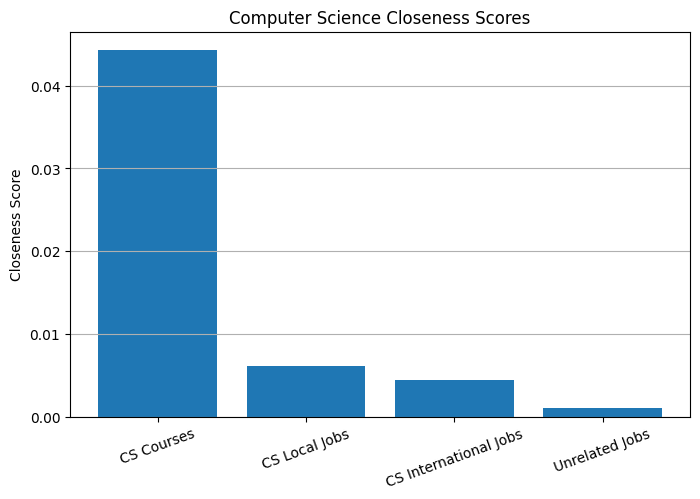

In [ ]:
# Bar Chart Visualization
plt.figure(figsize=(8, 5))
plt.bar(cs_results_df["Dataset"], cs_results_df["Closeness"])
plt.ylabel("Closeness Score")
plt.title("Computer Science Closeness Scores")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

Closeness Metric for Information Technology